# 4-Class Defect Detection — Custom Lightweight CNN
## (Inverse Residual Blocks + Coordinate Attention)

This notebook implements a **custom lightweight CNN** designed from scratch for 3D-printer defect detection.

### Architecture highlights
| Component | Details |
|-----------|--------|
| Backbone | MobileNet-style Inverse Residual Blocks |
| Attention | Coordinate Attention (CA) — lightweight, spatially-aware |
| Input | 224×224×3 |
| Output | 4-class Softmax (Cracking, Stringing, Warping, No_Defect) |
| Training | Two-phase: head-only → full fine-tune |

The dataset, preprocessing, augmentation, and training configuration are **identical** to the MobileNetV3 experiments for a fair comparison.

---
## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Shared hyper-parameters
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 4
CLASS_NAMES = ["Cracking", "Stringing", "Warping", "No_Defect"]

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU Available      : {tf.config.list_physical_devices('GPU')}")

2026-05-21 18:00:48.716419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779382848.822896     981 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779382848.852791     981 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-21 18:00:49.118007: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.18.0
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Load Dataset from Splitted Folders

Identical to MobileNetV3 experiments — images are loaded from `splitted data/` which contains
`train/`, `val/`, and `test/` sub-directories, each with one sub-folder per class.

In [3]:
BASE             = os.getcwd()
SPLITTED_DATA_DIR = os.path.join(BASE, "splitted data")

train_dir = os.path.join(SPLITTED_DATA_DIR, "train")
val_dir   = os.path.join(SPLITTED_DATA_DIR, "val")
test_dir  = os.path.join(SPLITTED_DATA_DIR, "test")


def get_paths_and_labels(folder_path):
    paths, labels = [], []
    class_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(folder_path, class_name)
        if os.path.isdir(class_dir):
            for f in os.listdir(class_dir):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(class_dir, f))
                    labels.append(class_map[class_name])
    return np.array(paths), np.array(labels)


train_paths, train_labels = get_paths_and_labels(train_dir)
val_paths,   val_labels   = get_paths_and_labels(val_dir)
test_paths,  test_labels  = get_paths_and_labels(test_dir)

# Shuffle training data
rng        = np.random.default_rng(SEED)
train_idx  = rng.permutation(len(train_paths))
train_paths  = train_paths[train_idx]
train_labels = train_labels[train_idx]

print(f"Dataset split summary:")
print(f"  Train : {len(train_paths)} images")
print(f"  Val   : {len(val_paths)}   images")
print(f"  Test  : {len(test_paths)}  images")

Dataset split summary:
  Train : 6187 images
  Val   : 773   images
  Test  : 776  images


---
## 3. Build tf.data Pipelines with Augmentation

Same preprocessing and augmentation as MobileNetV3 experiments:
- Pixel values normalised to `[0, 1]` (divide by 255)
- Random horizontal/vertical flip
- Random brightness jitter (±0.2)
- Random rotation (±20°)

> **Note:** Because we build the model from scratch (no pretrained backbone), we do **not** need
> `include_preprocessing=False` — there is no hidden preprocessing layer.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess(path, label):
    img   = tf.io.read_file(path)
    img   = tf.image.decode_jpeg(img, channels=3)
    img   = tf.image.resize(img, IMG_SIZE)
    img   = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label


_random_rotation = layers.RandomRotation(0.056)  # ≈ ±20 degrees


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = _random_rotation(img, training=True)
    return img, label


train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,             num_parallel_calls=AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Pipelines created successfully.")

I0000 00:00:1779382859.291460     981 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Pipelines created successfully.


---
## 4. Model Architecture

The model is composed of three custom building blocks:

```
Input (224×224×3)
  └─ Conv2D(32, 3×3, stride=2) → BN → ReLU6          [112×112×32]
  └─ InvResBlock(16,  stride=1, expand=1)              [112×112×16]
  └─ InvResBlock(24,  stride=2, expand=6)              [ 56×56 ×24]
  └─ InvResBlock(32,  stride=2, expand=6)              [ 28×28 ×32]
  └─ InvResBlock(64,  stride=2, expand=6)              [ 14×14 ×64]
  └─ InvResBlock(96,  stride=1, expand=6)              [ 14×14 ×96]
  └─ Conv2D(128, 1×1) → BN → ReLU6                   [ 14×14 ×128]
  └─ GlobalAveragePooling2D                            [128]
  └─ Dense(256, ReLU) → Dropout(0.3) → Dense(4, Softmax)
```

### Step 1 — Coordinate Attention (CA) Module

Coordinate Attention captures **long-range spatial dependencies** along each spatial direction
independently, making it more powerful than Squeeze-and-Excitation while staying lightweight.

**Algorithm:**
1. Pool along the **width** axis  → `(B, H, 1, C)` — encodes *horizontal* context
2. Pool along the **height** axis → `(B, 1, W, C)` — encodes *vertical* context
3. Transpose the W-pool to `(B, W, 1, C)` and **concatenate** both along the H axis → `(B, H+W, 1, C)`
4. Shared `1×1 Conv → BN → ReLU` transforms the concatenated descriptor
5. **Split** back into H and W branches, each followed by `1×1 Conv → Sigmoid`
6. Multiply both attention maps element-wise with the original feature map

In [6]:
class CoordinateAttention(layers.Layer):
    """Coordinate Attention module.

    Args:
        reduction (int): Channel reduction ratio for the shared intermediate
            representation. Defaults to 32.
    """

    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]  # number of input channels
        mid_ch = max(8, C // self.reduction)

        # Shared branch: transforms the concatenated H+W pooled descriptor
        self.shared_conv = layers.Conv2D(mid_ch, 1, padding='same', use_bias=False)
        self.bn           = layers.BatchNormalization()
        self.relu         = layers.ReLU(max_value=6.0)

        # Per-direction 1×1 projections back to C channels
        self.conv_h = layers.Conv2D(C, 1, padding='same')
        self.conv_w = layers.Conv2D(C, 1, padding='same')

        super().build(input_shape)

    def call(self, x, training=False):
        # x shape: (B, H, W, C)
        H = tf.shape(x)[1]

        # Step 1 — directional global pooling
        # Pool along W → encodes each row     → (B, H, 1, C)
        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)
        # Pool along H → encodes each column  → (B, 1, W, C)
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)

        # Transpose pool_w to (B, W, 1, C) so we can concatenate on the H axis
        pool_w_t = tf.transpose(pool_w, perm=[0, 2, 1, 3])

        # Step 2 — concatenate along the spatial H axis → (B, H+W, 1, C)
        y = tf.concat([pool_h, pool_w_t], axis=1)

        # Step 3 — shared transformation
        y = self.shared_conv(y)
        y = self.bn(y, training=training)
        y = self.relu(y)

        # Step 4 — split back into H and W descriptors
        y_h = y[:, :H, :, :]   # (B, H, 1, mid_ch)
        y_w = y[:, H:, :, :]   # (B, W, 1, mid_ch)

        # Step 5 — attention maps via sigmoid
        a_h = tf.sigmoid(self.conv_h(y_h))            # (B, H, 1, C)
        a_w = tf.sigmoid(self.conv_w(y_w))            # (B, W, 1, C)
        a_w = tf.transpose(a_w, perm=[0, 2, 1, 3])   # (B, 1, W, C)

        # Step 6 — apply spatial attention
        return x * a_h * a_w

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg


print("✅ CoordinateAttention layer defined.")

✅ CoordinateAttention layer defined.


### Step 2 — Inverse Residual Block with Coordinate Attention

Each block follows the **inverted residual** pattern from MobileNetV2:

```
Input
  ├─ 1×1 Conv (expand channels by ×expand) → BN → ReLU6   ← point-wise expansion
  ├─ 3×3 Depthwise Conv (stride)           → BN → ReLU6   ← spatial filtering
  ├─ Coordinate Attention module                           ← spatial re-weighting
  ├─ 1×1 Conv (project back to out_channels) → BN          ← point-wise projection
  └─ Skip connection (if stride=1 and in_ch == out_ch)     ← residual
```

> When `expand=1` (first block), the expansion step is skipped to avoid redundancy.

In [7]:
def inv_res_block(x, out_channels, stride=1, expand=6, name_prefix="irb"):
    """Inverse Residual Block with Coordinate Attention.

    Args:
        x            : Input tensor.
        out_channels : Number of output channels.
        stride       : Stride of the depthwise conv (1 or 2).
        expand       : Channel expansion factor.
        name_prefix  : Prefix for layer names.

    Returns:
        Output tensor.
    """
    in_channels = x.shape[-1]
    mid_channels = in_channels * expand
    shortcut = x

    # ── 1. Point-wise Expansion ──────────────────────────────────────────────
    # Skip when expand==1 to avoid unnecessary computation
    if expand != 1:
        x = layers.Conv2D(
            mid_channels, 1, padding='same', use_bias=False,
            name=f"{name_prefix}_expand_conv"
        )(x)
        x = layers.BatchNormalization(name=f"{name_prefix}_expand_bn")(x)
        x = layers.ReLU(max_value=6.0, name=f"{name_prefix}_expand_relu")(x)

    # ── 2. Depthwise Spatial Filtering ───────────────────────────────────────
    x = layers.DepthwiseConv2D(
        3, strides=stride, padding='same', use_bias=False,
        name=f"{name_prefix}_dw_conv"
    )(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_dw_bn")(x)
    x = layers.ReLU(max_value=6.0, name=f"{name_prefix}_dw_relu")(x)

    # ── 3. Coordinate Attention ───────────────────────────────────────────────
    x = CoordinateAttention(reduction=32, name=f"{name_prefix}_ca")(x)

    # ── 4. Point-wise Projection ─────────────────────────────────────────────
    x = layers.Conv2D(
        out_channels, 1, padding='same', use_bias=False,
        name=f"{name_prefix}_proj_conv"
    )(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_proj_bn")(x)
    # NOTE: No activation after projection (standard practice)

    # ── 5. Skip Connection ────────────────────────────────────────────────────
    # Only apply when spatial resolution is preserved AND channels match
    if stride == 1 and in_channels == out_channels:
        x = layers.Add(name=f"{name_prefix}_add")([shortcut, x])

    return x


print("✅ inv_res_block() function defined.")

✅ inv_res_block() function defined.


### Step 3 & 4 — Backbone Stack + Classification Head

The backbone progressively downsamples the spatial resolution from 224×224 down to 14×14
while increasing the number of feature channels.  
A final pointwise conv compresses channels to 128 before global pooling.

| Stage | Op | Output shape | Params |
|-------|----|-------------|--------|
| 0 | Conv2D(32, 3×3, s=2) + BN + ReLU6 | 112×112×32 | |
| 1 | InvResBlock(16, s=1, t=1) | 112×112×16 | residual |
| 2 | InvResBlock(24, s=2, t=6) | 56×56×24 | |
| 3 | InvResBlock(32, s=2, t=6) | 28×28×32 | residual |
| 4 | InvResBlock(64, s=2, t=6) | 14×14×64 | |
| 5 | InvResBlock(96, s=1, t=6) | 14×14×96 | |
| 6 | Conv2D(128, 1×1) + BN + ReLU6 | 14×14×128 | |
| 7 | GlobalAveragePooling2D | 128 | |
| 8 | Dense(256) + Dropout(0.3) + Dense(4) | 4 | |

In [8]:
def build_custom_ca_cnn(num_classes=4, input_shape=(224, 224, 3)):
    """Build the full Custom Lightweight CNN with CA."""
    inputs = layers.Input(shape=input_shape, name="input")

    # ── Stem ─────────────────────────────────────────────────────────────────
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(max_value=6.0, name="stem_relu")(x)
    # Output: 112×112×32

    # ── Inverse Residual Blocks ───────────────────────────────────────────────
    x = inv_res_block(x, out_channels=16, stride=1, expand=1,  name_prefix="irb1")
    # Output: 112×112×16  (residual: in==out, stride==1)

    x = inv_res_block(x, out_channels=24, stride=2, expand=6,  name_prefix="irb2")
    # Output: 56×56×24

    x = inv_res_block(x, out_channels=32, stride=2, expand=6,  name_prefix="irb3")
    # Output: 28×28×32

    x = inv_res_block(x, out_channels=64, stride=2, expand=6,  name_prefix="irb4")
    # Output: 14×14×64

    x = inv_res_block(x, out_channels=96, stride=1, expand=6,  name_prefix="irb5")
    # Output: 14×14×96  (no residual: 64 ≠ 96)

    # ── Transition Conv ───────────────────────────────────────────────────────
    x = layers.Conv2D(128, 1, padding='same', use_bias=False, name="trans_conv")(x)
    x = layers.BatchNormalization(name="trans_bn")(x)
    x = layers.ReLU(max_value=6.0, name="trans_relu")(x)
    # Output: 14×14×128

    # ── Classification Head ───────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation='relu', name="fc1")(x)
    x = layers.Dropout(0.3, name="drop")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    return keras.Model(inputs, outputs, name="Custom_CA_CNN")


model = build_custom_ca_cnn(num_classes=NUM_CLASSES)
model.summary()

Model: "Custom_CA_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv2D)              │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (ReLU)                │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb1_dw_conv (DepthwiseConv2D)  │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb1_dw_bn (BatchNormalization) │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb1_dw_relu (ReLU)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb1_ca (CoordinateAttention)   │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb1_proj_conv (Conv2D)         │ (None, 112, 112, 16)   │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb1_proj_bn                    │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_expand_conv (Conv2D)       │ (None, 112, 112, 96)   │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_expand_bn                  │ (None, 112, 112, 96)   │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_expand_relu (ReLU)         │ (None, 112, 112, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_dw_conv (DepthwiseConv2D)  │ (None, 56, 56, 96)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_dw_bn (BatchNormalization) │ (None, 56, 56, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_dw_relu (ReLU)             │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_ca (CoordinateAttention)   │ (None, 56, 56, 96)     │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_proj_conv (Conv2D)         │ (None, 56, 56, 24)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb2_proj_bn                    │ (None, 56, 56, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb3_expand_conv (Conv2D)       │ (None, 56, 56, 144)    │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb3_expand_bn                  │ (None, 56, 56, 144)    │           576 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb3_expand_relu (ReLU)         │ (None, 56, 56, 144)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irb3_dw_conv (DepthwiseConv2D)  │ (None, 28, 28, 144)    │         1,29

 Total params: 182,180 (711.64 KB)

 Trainable params: 177,980 (695.23 KB)

 Non-trainable params: 4,200 (16.41 KB)

---
## 5. Phase 1 Training — Full Network from Scratch

Since we train from scratch (no pretrained weights), **all** layers are trainable from the start.
Phase 1 uses a moderate learning rate of `1e-4` to allow the network to explore the loss landscape.

**Callbacks:**
- `EarlyStopping` — patience=10, restores best weights
- `ReduceLROnPlateau` — halves LR after 5 stagnant epochs, min LR = 1e-7
- `ModelCheckpoint` — saves only the best weights to disk

In [8]:
BEST_P1 = "best_custom_ca_cnn_phase1.weights.h5"

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_p1 = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_P1, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=1
    ),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_p1,
)
print("✅ Phase 1 Training Complete.")

Epoch 1/50


I0000 00:00:1779347828.445261    4239 service.cc:148] XLA service 0x7a0b7c003dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779347828.445618    4239 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-21 08:17:08.853279: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779347830.061637    4239 cuda_dnn.cc:529] Loaded cuDNN version 92000
I0000 00:00:1779347846.091736    4239 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5380 - loss: 1.0425

2026-05-21 08:18:17.418680: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'loop_multiply_transpose_fusion_2', 256 bytes spill stores, 252 bytes spill loads



194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5394 - loss: 1.0397
Epoch 1: val_loss improved from None to 1.46688, saving model to best_custom_ca_cnn_phase1.weights.h5

Epoch 1: finished saving model to best_custom_ca_cnn_phase1.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 97s 309ms/step - accuracy: 0.6675 - loss: 0.7689 - val_accuracy: 0.2147 - val_loss: 1.4669 - learning_rate: 1.0000e-04
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7860 - loss: 0.4124
Epoch 2: val_loss did not improve from 1.46688
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 201ms/step - accuracy: 0.7996 - loss: 0.3827 - val_accuracy: 0.2147 - val_loss: 1.8937 - learning_rate: 1.0000e-04
Epoch 3/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8238 - loss: 0.3350
Epoch 3: val_loss did not improve from 1.46688
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 202ms/step - accuracy: 0.8283 - loss: 0.3226 - val_accuracy: 0.3066 - val_loss: 1.6609 - learning_rate: 1.0000e-04
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━

### Phase 1 — Training History

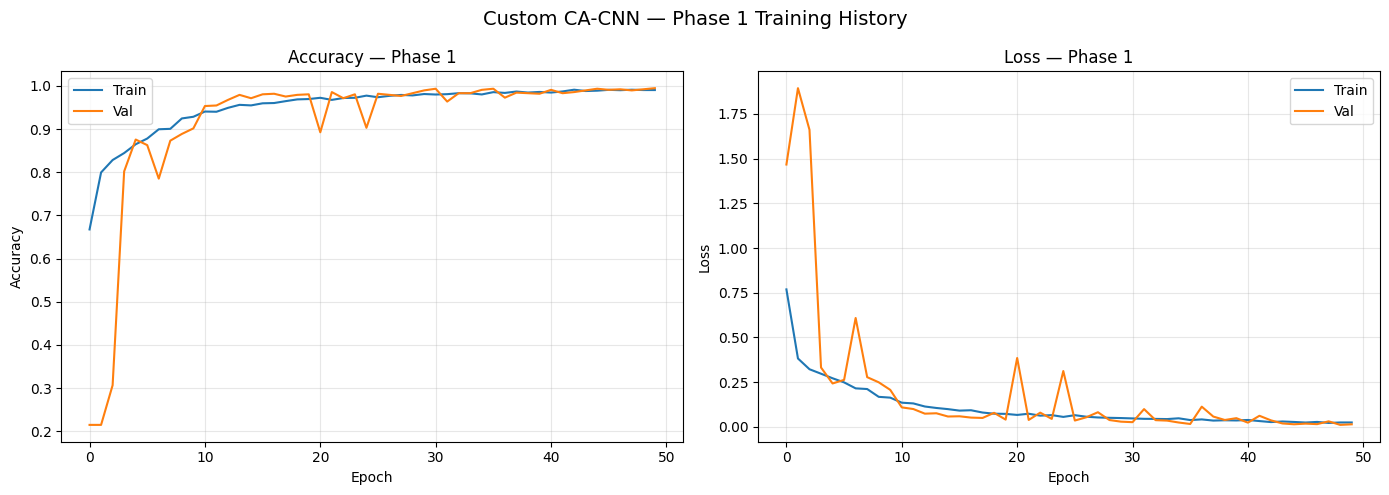

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_p1.history["accuracy"],     label="Train")
axes[0].plot(history_p1.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy — Phase 1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_p1.history["loss"],     label="Train")
axes[1].plot(history_p1.history["val_loss"], label="Val")
axes[1].set_title("Loss — Phase 1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Custom CA-CNN — Phase 1 Training History", fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Phase 2 — Fine-Tuning at Lower Learning Rate

After Phase 1 converges, we reload the best checkpoint and continue training with
a **10× smaller learning rate** (`lr = 1e-5`).  
This second phase acts as a refinement step — the optimizer takes smaller steps that
are less likely to escape the good minimum found in Phase 1.

> Because the model is trained from scratch, we fine-tune **all** layers (no freezing).
> The lower LR prevents catastrophic forgetting of what was learned in Phase 1.

In [10]:
BEST_FT = "best_custom_ca_cnn_finetuned.weights.h5"

# Reload Phase 1 best weights
model.load_weights(BEST_P1)
print("✅ Phase-1 best weights loaded.")

# Recompile with lower LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_ft = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_FT, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=1
    ),
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_ft,
)
print("✅ Fine-Tuning Complete.")

✅ Phase-1 best weights loaded.
Epoch 1/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9906 - loss: 0.0213

2026-05-21 08:58:38.136507: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'loop_multiply_transpose_fusion_2', 256 bytes spill stores, 252 bytes spill loads



194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9906 - loss: 0.0212
Epoch 1: val_loss improved from None to 0.01181, saving model to best_custom_ca_cnn_finetuned.weights.h5

Epoch 1: finished saving model to best_custom_ca_cnn_finetuned.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 96s 296ms/step - accuracy: 0.9914 - loss: 0.0210 - val_accuracy: 0.9974 - val_loss: 0.0118 - learning_rate: 1.0000e-05
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9896 - loss: 0.0243
Epoch 2: val_loss did not improve from 0.01181
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 208ms/step - accuracy: 0.9913 - loss: 0.0228 - val_accuracy: 0.9974 - val_loss: 0.0136 - learning_rate: 1.0000e-05
Epoch 3/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9958 - loss: 0.0159
Epoch 3: val_loss improved from 0.01181 to 0.01152, saving model to best_custom_ca_cnn_finetuned.weights.h5

Epoch 3: finished saving model to best_custom_ca_cnn_finetuned.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 209ms/st

### Phase 2 — Fine-Tuning History

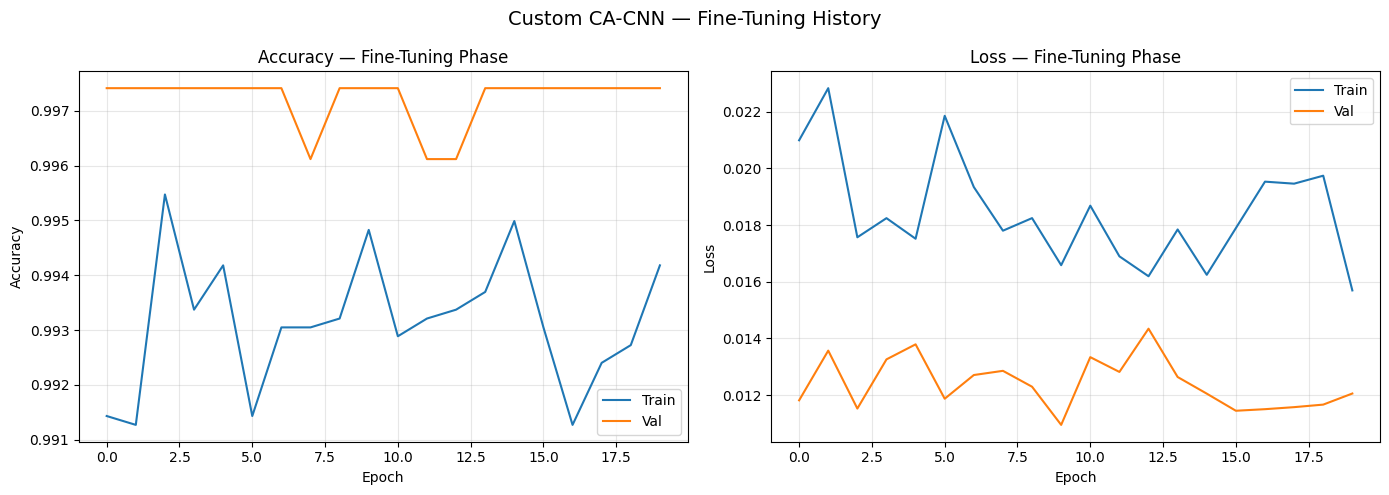

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ft.history["accuracy"],     label="Train")
axes[0].plot(history_ft.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy — Fine-Tuning Phase")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_ft.history["loss"],     label="Train")
axes[1].plot(history_ft.history["val_loss"], label="Val")
axes[1].set_title("Loss — Fine-Tuning Phase")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Custom CA-CNN — Fine-Tuning History", fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Evaluation on Test Set

Load the best fine-tuned weights and evaluate on the held-out test split.

In [12]:
# Load best fine-tuned weights
model.load_weights(BEST_FT)
print("✅ Best fine-tuned weights loaded.")

# Predictions
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_labels

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nCustom CA-CNN Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

✅ Best fine-tuned weights loaded.
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 304ms/step

Custom CA-CNN Test Accuracy: 0.9974 (99.74%)

              precision    recall  f1-score   support

    Cracking       1.00      1.00      1.00       167
   Stringing       0.99      1.00      1.00       256
     Warping       1.00      1.00      1.00       171
   No_Defect       1.00      0.99      0.99       182

    accuracy                           1.00       776
   macro avg       1.00      1.00      1.00       776
weighted avg       1.00      1.00      1.00       776



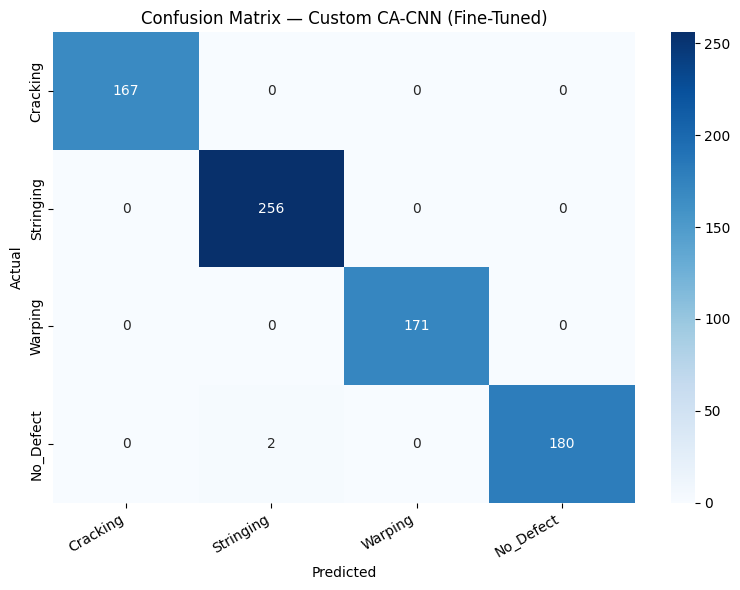

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Custom CA-CNN (Fine-Tuned)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [10]:
BEST_P1 = "best_custom_ca_cnn_phase1.weights.h5"
# Load best fine-tuned weights
model.load_weights(BEST_P1)
print("Phase 1 weights loaded.")

# Predictions
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_labels

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nCustom CA-CNN Test Accuracy phase 1: {acc:.4f} ({acc*100:.2f}%)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Phase 1 weights loaded.
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step

Custom CA-CNN Test Accuracy phase 1: 0.9987 (99.87%)

              precision    recall  f1-score   support

    Cracking       1.00      1.00      1.00       167
   Stringing       1.00      1.00      1.00       256
     Warping       1.00      1.00      1.00       171
   No_Defect       1.00      0.99      1.00       182

    accuracy                           1.00       776
   macro avg       1.00      1.00      1.00       776
weighted avg       1.00      1.00      1.00       776



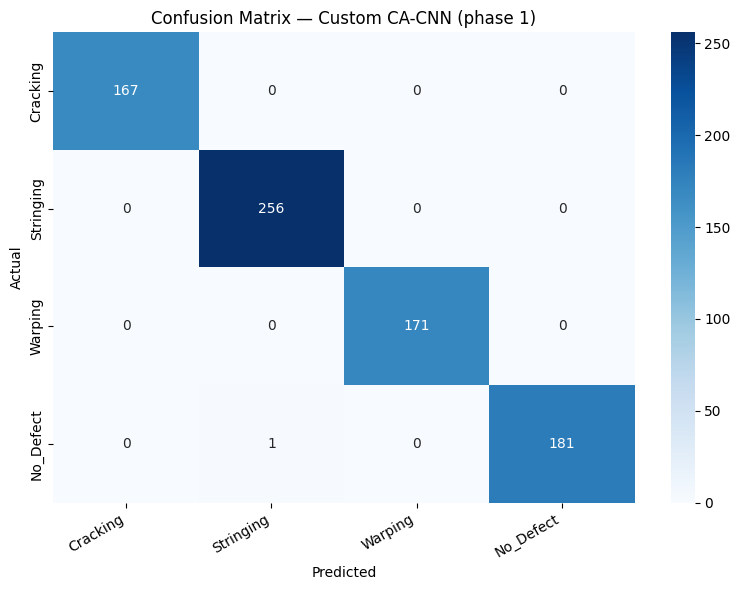

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Custom CA-CNN (phase 1)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## 8. Results Comparison

Place the Custom CA-CNN result alongside the pretrained MobileNetV3 baselines.

In [6]:
# Update acc_custom after running evaluation above


results = [
    {"Model": "MobileNetV2 (Last 20 FT)",     "Test Accuracy": 0.9923, "F1 Macro": 0.99},
    {"Model": "MobileNetV2 (All Layers FT)",  "Test Accuracy": 0.9948, "F1 Macro": 1.00},
    {"Model": "MobileNetV3Small (Last 20 FT)","Test Accuracy": 0.9871,   "F1 Macro": 0.99},
    {"Model": "MobileNetV3Large (Last 20 FT)","Test Accuracy": 0.9935,   "F1 Macro": 0.99},
    {"Model": "Custom CA-CNN (Fine-Tuned)",    "Test Accuracy": 0.9974, "F1 Macro": 0.99},
]

df = pd.DataFrame(results)
print(df.to_markdown(index=False))

| Model                         |   Test Accuracy |   F1 Macro |
|:------------------------------|----------------:|-----------:|
| MobileNetV2 (Last 20 FT)      |          0.9923 |       0.99 |
| MobileNetV2 (All Layers FT)   |          0.9948 |       1    |
| MobileNetV3Small (Last 20 FT) |          0.9871 |       0.99 |
| MobileNetV3Large (Last 20 FT) |          0.9935 |       0.99 |
| Custom CA-CNN (Fine-Tuned)    |          0.9974 |       0.99 |
